In [1]:
'''Loading Data from Database.
Step 1 — Connect to SQLite'''

'Loading Data from Database.\nStep 1 — Connect to SQLite'

In [2]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("sqlite:///D:\Data science Inttruvu.ai\Capstone projects for data science (extracted)\Database.db")


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

import joblib

In [4]:
#Step 2 — Verify Tables

In [5]:
import sqlite3
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

pd.read_sql(query, engine)


,name
0,Electric_cars
1,Fraud_detection
2,Heart_disease
3,Insurance_Prediction
4,TripAdviser_Reviews
5,Ecommerce_data
6,Automobile_data
7,Supermarket_data


In [6]:
#Step 3 — Load Sample Data for EDA

In [7]:
query = """
SELECT *
FROM Electric_cars
LIMIT 100000
"""

df_M = pd.read_sql(query, engine)


In [8]:
df_M.shape

(100000, 9)

In [93]:
df_M.head(50)

,profile_id,u_q,coolant,u_d,motor_speed,i_d,i_q,ambient,pm,current_magnitude,voltage_magnitude,power_proxy
0,17,-0.450682,18.805172,-0.350055,0.002866,0.004419,0.000328,19.850691,24.554214,0.004431,0.570659,0.002529
1,17,-0.325737,18.818571,-0.305803,0.000257,0.000606,-0.000785,19.850672,24.538078,0.000992,0.446789,0.000443
2,17,-0.440864,18.828770,-0.372503,0.002355,0.001290,0.000386,19.850657,24.544693,0.001346,0.577165,0.000777
3,17,-0.327026,18.835567,-0.316199,0.006105,0.000026,0.002046,19.850647,24.554018,0.002046,0.454893,0.000931
4,17,-0.471150,18.857033,-0.332272,0.003133,-0.064317,0.037184,19.850639,24.565397,0.074292,0.576530,0.042832
5,17,-0.538973,18.901548,0.009147,0.009636,-0.613635,0.336747,19.850634,24.573601,0.699962,0.539050,0.377315
6,17,-0.653148,18.941711,0.238890,0.001337,-1.005647,0.554211,19.850630,24.576578,1.148249,0.695465,0.798567
7,17,-0.758392,18.960861,0.395099,0.001422,-1.288384,0.706370,19.850628,24.574949,1.469317,0.855138,1.256469
8,17,-0.727128,18.973545,0.546623,0.000577,-1.490530,0.817339,19.850626,24.567080,1.699919,0.909677,1.546377
9,17,-0.874307,18.987812,0.578944,-0.001248,-1.634464,0.898013,19.850624,24.553242,1.864912,1.048613,1.955572


In [10]:
query = """
SELECT *
FROM Electric_cars
LIMIT 5000
"""
df_s = pd.read_sql(query, engine)


In [11]:
df_s.head()

,profile_id,u_q,coolant,u_d,motor_speed,i_d,i_q,ambient,pm
0,17,-0.450681508,18.80517197,-0.350054592,0.002865568,0.004419137,0.000328102,19.85069084,24.55421448
1,17,-0.325737,18.81857109,-0.305803001,0.000256782,0.000605872,-0.000785353,19.85067177,24.53807831
2,17,-0.440864027,18.82876968,-0.372502625,0.002354971,0.001289587,0.000386468,19.85065651,24.54469299
3,17,-0.327025682,18.83556747,-0.316198707,0.006104666,2.56E-05,0.002045661,19.85064697,24.55401802
4,17,-0.47115013,18.85703278,-0.332272142,0.003132823,-0.064316779,0.037183776,19.85063934,24.56539726


In [12]:
df_s.shape

(5000, 9)

In [13]:
query = """
SELECT *
FROM Electric_cars
"""
df_f = pd.read_sql(query, engine)


In [14]:
df_f.shape

(1048575, 9)

In [15]:
# Step 4 :Exploratory Data Analysis (EDA) & Profiling  
## Permanent Magnet Temperature Prediction (PMSM)

'''This notebook performs exploratory data analysis and data profiling on
sensor data collected from a Permanent Magnet Synchronous Motor (PMSM).

The goal is to understand:
- The structure and quality of the data
- Relationships between electrical, thermal, and operational features
- How these features influence the permanent magnet temperature (`pm`)'''


'This notebook performs exploratory data analysis and data profiling on\nsensor data collected from a Permanent Magnet Synchronous Motor (PMSM).\n\nThe goal is to understand:\n- The structure and quality of the data\n- Relationships between electrical, thermal, and operational features\n- How these features influence the permanent magnet temperature (`pm`)'

In [16]:
df_f.isnull().sum()


profile_id     0
u_q            0
coolant        0
u_d            0
motor_speed    0
i_d            0
i_q            0
ambient        0
pm             0
dtype: int64

In [17]:
plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

In [18]:
df_M.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   profile_id   100000 non-null  object
 1   u_q          100000 non-null  object
 2   coolant      100000 non-null  object
 3   u_d          100000 non-null  object
 4   motor_speed  100000 non-null  object
 5   i_d          100000 non-null  object
 6   i_q          100000 non-null  object
 7   ambient      100000 non-null  object
 8   pm           100000 non-null  object
dtypes: object(9)
memory usage: 6.9+ MB


In [19]:
df_s.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   profile_id   5000 non-null   object
 1   u_q          5000 non-null   object
 2   coolant      5000 non-null   object
 3   u_d          5000 non-null   object
 4   motor_speed  5000 non-null   object
 5   i_d          5000 non-null   object
 6   i_q          5000 non-null   object
 7   ambient      5000 non-null   object
 8   pm           5000 non-null   object
dtypes: object(9)
memory usage: 351.7+ KB


In [20]:
df_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   profile_id   1048575 non-null  object
 1   u_q          1048575 non-null  object
 2   coolant      1048575 non-null  object
 3   u_d          1048575 non-null  object
 4   motor_speed  1048575 non-null  object
 5   i_d          1048575 non-null  object
 6   i_q          1048575 non-null  object
 7   ambient      1048575 non-null  object
 8   pm           1048575 non-null  object
dtypes: object(9)
memory usage: 72.0+ MB


In [21]:
df_M.describe()

,profile_id,u_q,coolant,u_d,motor_speed,i_d,i_q,ambient,pm
count,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,7,91733,94005,91955,8448,66511,64646,93251,99334
top,12,131.2702179,20.56766319,,,-122.9724503,,19.85062027,45.22201157
freq,21438,7,10,4096,4096,50,2377,2031,3


In [22]:
df_f.describe()

,profile_id,u_q,coolant,u_d,motor_speed,i_d,i_q,ambient,pm
count,1048575,1048575,1048575,1048575,1048575,1048575,1048575,1048575,1048575
unique,55,989487,839152,972149,472987,762679,724716,909528,1034758
top,20,131.8004913,81.48964234,,,-43.51179504,,19.85062027,35.60079956
freq,42951,16,8253,44094,44094,149,24089,17196,4


In [23]:
#Step 5-  Convert all columns except profile_id to numeric
cols_to_fix = [
'u_q','coolant','u_d','motor_speed',
'i_d','i_q','ambient','pm'
]

for col in cols_to_fix:

    df_f[col] = pd.to_numeric(df_f[col], errors='coerce')
    df_M[col] = pd.to_numeric(df_M[col], errors='coerce')
    df_s[col] = pd.to_numeric(df_s[col], errors='coerce')


In [24]:
df_f['profile_id'] = pd.to_numeric(df_f['profile_id'], errors='coerce').astype('Int64')
df_M['profile_id'] = pd.to_numeric(df_M['profile_id'], errors='coerce').astype('Int64')
df_s['profile_id'] = pd.to_numeric(df_s['profile_id'], errors='coerce').astype('Int64')

In [25]:
df_M.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   profile_id   97623 non-null   Int64  
 1   u_q          100000 non-null  float64
 2   coolant      100000 non-null  float64
 3   u_d          95904 non-null   float64
 4   motor_speed  95904 non-null   float64
 5   i_d          100000 non-null  float64
 6   i_q          97623 non-null   float64
 7   ambient      100000 non-null  float64
 8   pm           100000 non-null  float64
dtypes: Int64(1), float64(8)
memory usage: 7.0 MB


In [26]:
df_f.isnull().sum()

profile_id     24089
u_q                0
coolant            0
u_d            44094
motor_speed    44094
i_d                0
i_q            24089
ambient            0
pm                 0
dtype: int64

In [27]:
df_M.isnull().sum()

profile_id     2377
u_q               0
coolant           0
u_d            4096
motor_speed    4096
i_d               0
i_q            2377
ambient           0
pm                0
dtype: int64

In [28]:
df_f.describe()

,profile_id,u_q,coolant,u_d,motor_speed,i_d,i_q,ambient,pm
count,1024486.0,1.048575e+06,1.048575e+06,1.004481e+06,1.004481e+06,1.048575e+06,1.024486e+06,1.048575e+06,1.048575e+06
mean,35.498656,5.333733e+01,3.232322e+01,-2.897310e+01,2.209562e+03,-7.092833e+01,4.328784e+01,2.423961e+01,5.691077e+01
std,25.06037,4.336464e+01,2.027951e+01,6.222443e+01,1.874140e+03,6.660061e+01,9.158756e+01,1.940425e+00,2.001114e+01
min,2.0,-2.529093e+01,1.376190e+01,-1.315304e+02,-2.755491e+02,-2.780036e+02,-2.934268e+02,1.410069e+01,2.085696e+01
25%,14.0,1.209668e+01,1.860544e+01,-8.524918e+01,3.834424e+02,-1.192647e+02,1.096399e+00,2.309487e+01,3.900360e+01
50%,29.0,4.752466e+01,1.926167e+01,-7.620561e+00,1.999976e+03,-5.073550e+01,2.992296e+01,2.411081e+01,5.760014e+01
75%,57.0,8.757509e+01,4.179416e+01,8.298083e-01,3.749966e+03,-2.980322e+00,1.131802e+02,2.591768e+01,7.169332e+01
max,81.0,1.330313e+02,1.015985e+02,1.314698e+02,6.000015e+03,5.189670e-02,3.017079e+02,3.071420e+01,1.136066e+02


In [29]:
df_M.describe()

,profile_id,u_q,coolant,u_d,motor_speed,i_d,i_q,ambient,pm
count,97623.0,100000.000000,100000.000000,95904.000000,95904.000000,100000.000000,97623.000000,100000.000000,100000.000000
mean,16.602307,74.152956,18.831494,-52.568272,2792.032164,-83.730286,76.106034,22.583021,49.742720
std,9.838511,41.060035,0.443702,49.403097,1628.229931,65.424313,74.901776,1.293746,16.156608
min,2.0,-0.974433,15.594865,-131.247696,-0.006299,-246.089752,-0.003094,18.558733,20.856956
25%,12.0,43.387477,18.521117,-96.021666,1999.972778,-122.972771,1.096944,21.988417,37.341474
50%,17.0,83.152515,18.795531,-43.006042,2249.990234,-84.627251,53.460918,22.861649,46.926344
75%,21.0,97.284302,19.175550,-5.221918,4499.957520,-43.510036,132.617355,23.337174,58.416964
max,32.0,131.628311,21.393656,2.676198,4999.971191,0.004419,242.425613,25.875355,91.506210


In [30]:
#Step 6 checking for duplicates and missing values like doing DATA Cleaning.
df_f.duplicated().sum()


np.int64(0)

In [31]:
df_M.duplicated().sum()


np.int64(0)

In [32]:
missing_counts = df_f.isnull().sum()
missing_percent = (missing_counts / len(df_f)) * 100

pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})


,missing_count,missing_percent
profile_id,24089,2.297308
u_q,0,0.000000
coolant,0,0.000000
u_d,44094,4.205136
motor_speed,44094,4.205136
i_d,0,0.000000
i_q,24089,2.297308
ambient,0,0.000000
pm,0,0.000000


In [33]:
missing_counts = df_M.isnull().sum()
missing_percent = (missing_counts / len(df_M)) * 100

pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})


,missing_count,missing_percent
profile_id,2377,2.377
u_q,0,0.000
coolant,0,0.000
u_d,4096,4.096
motor_speed,4096,4.096
i_d,0,0.000
i_q,2377,2.377
ambient,0,0.000
pm,0,0.000


In [34]:
#DATA cleaning- Missing value imputation
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df_f[cols_to_fix] = imputer.fit_transform(df_f[cols_to_fix])
df_M[cols_to_fix] = imputer.fit_transform(df_M[cols_to_fix])
df_s[cols_to_fix] = imputer.fit_transform(df_s[cols_to_fix])

In [35]:
df_f.describe()

,profile_id,u_q,coolant,u_d,motor_speed,i_d,i_q,ambient,pm
count,1024486.0,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,35.498656,5.333733e+01,3.232322e+01,-2.807520e+01,2.200749e+03,-7.092833e+01,4.298081e+01,2.423961e+01,5.691077e+01
std,25.06037,4.336464e+01,2.027951e+01,6.105266e+01,1.834794e+03,6.660061e+01,9.055156e+01,1.940425e+00,2.001114e+01
min,2.0,-2.529093e+01,1.376190e+01,-1.315304e+02,-2.755491e+02,-2.780036e+02,-2.934268e+02,1.410069e+01,2.085696e+01
25%,14.0,1.209668e+01,1.860544e+01,-8.374624e+01,4.999775e+02,-1.192647e+02,1.096509e+00,2.309487e+01,3.900360e+01
50%,29.0,4.752466e+01,1.926167e+01,-7.620561e+00,1.999976e+03,-5.073550e+01,2.992296e+01,2.411081e+01,5.760014e+01
75%,57.0,8.757509e+01,4.179416e+01,7.688221e-01,3.575580e+03,-2.980322e+00,1.130323e+02,2.591768e+01,7.169332e+01
max,81.0,1.330313e+02,1.015985e+02,1.314698e+02,6.000015e+03,5.189670e-02,3.017079e+02,3.071420e+01,1.136066e+02


In [36]:
df_f.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   profile_id   1024486 non-null  Int64  
 1   u_q          1048575 non-null  float64
 2   coolant      1048575 non-null  float64
 3   u_d          1048575 non-null  float64
 4   motor_speed  1048575 non-null  float64
 5   i_d          1048575 non-null  float64
 6   i_q          1048575 non-null  float64
 7   ambient      1048575 non-null  float64
 8   pm           1048575 non-null  float64
dtypes: Int64(1), float64(8)
memory usage: 73.0 MB


In [37]:
missing_counts = df_f.isna().sum()
missing_percent = (missing_counts / len(df_f)) * 100

pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

,missing_count,missing_percent
profile_id,24089,2.297308
u_q,0,0.000000
coolant,0,0.000000
u_d,0,0.000000
motor_speed,0,0.000000
i_d,0,0.000000
i_q,0,0.000000
ambient,0,0.000000
pm,0,0.000000


In [38]:
df_M.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   profile_id   97623 non-null   Int64  
 1   u_q          100000 non-null  float64
 2   coolant      100000 non-null  float64
 3   u_d          100000 non-null  float64
 4   motor_speed  100000 non-null  float64
 5   i_d          100000 non-null  float64
 6   i_q          100000 non-null  float64
 7   ambient      100000 non-null  float64
 8   pm           100000 non-null  float64
dtypes: Int64(1), float64(8)
memory usage: 7.0 MB


In [39]:
df_M.describe()

,profile_id,u_q,coolant,u_d,motor_speed,i_d,i_q,ambient,pm
count,97623.0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,16.602307,74.152956,18.831494,-52.176603,2769.830126,-83.730286,75.567760,22.583021,49.742720
std,9.838511,41.060035,0.443702,48.417840,1598.149820,65.424313,74.086558,1.293746,16.156608
min,2.0,-0.974433,15.594865,-131.247696,-0.006299,-246.089752,-0.003094,18.558733,20.856956
25%,12.0,43.387477,18.521117,-95.528492,1999.974365,-122.972771,1.097009,21.988417,37.341474
50%,17.0,83.152515,18.795531,-43.006042,2249.990234,-84.627251,53.460918,22.861649,46.926344
75%,21.0,97.284302,19.175550,-5.241061,4499.957031,-43.510036,132.617325,23.337174,58.416964
max,32.0,131.628311,21.393656,2.676198,4999.971191,0.004419,242.425613,25.875355,91.506210


In [40]:
missing_counts = df_M.isna().sum()
missing_percent = (missing_counts / len(df_M)) * 100

pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})


,missing_count,missing_percent
profile_id,2377,2.377
u_q,0,0.000
coolant,0,0.000
u_d,0,0.000
motor_speed,0,0.000
i_d,0,0.000
i_q,0,0.000
ambient,0,0.000
pm,0,0.000


In [41]:
#STEP 7 — Separate FEATURES & TARGET

In [42]:
TARGET = 'pm'
df_M = df_M.apply(pd.to_numeric, errors='coerce')

X = df_M.drop(columns=[TARGET])
y = df_M[TARGET]


In [43]:
TARGET = 'pm'
df_f = df_f.apply(pd.to_numeric, errors='coerce')

X_f = df_f.drop(columns=[TARGET])
y_f = df_f[TARGET]


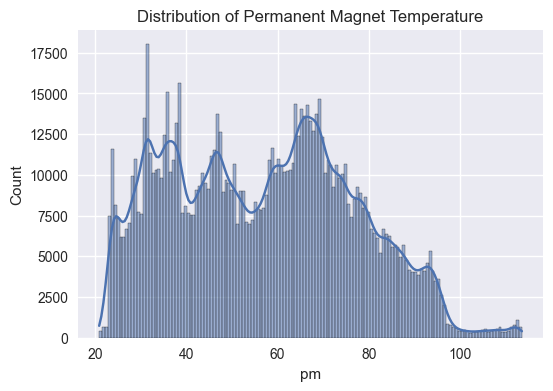

In [44]:
#Step 8 — DISTRIBUTION ANALYSIS (EDA Core) Target Distribution
plt.figure(figsize=(6,4))
sns.histplot(df_f['pm'], kde=True)
plt.title("Distribution of Permanent Magnet Temperature")
plt.show()



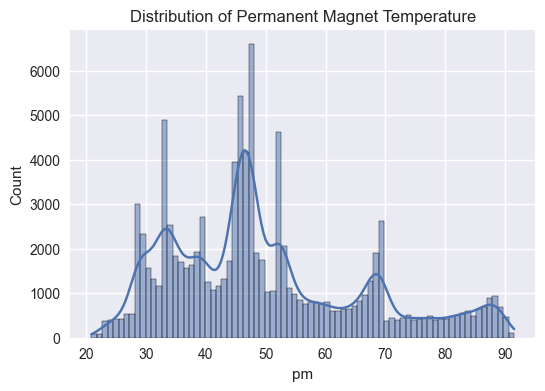

In [45]:
#Step 8 — DISTRIBUTION ANALYSIS (EDA Core) Target Distribution
plt.figure(figsize=(6,4))
sns.histplot(df_M['pm'], kde=True)
plt.title("Distribution of Permanent Magnet Temperature")
plt.show()


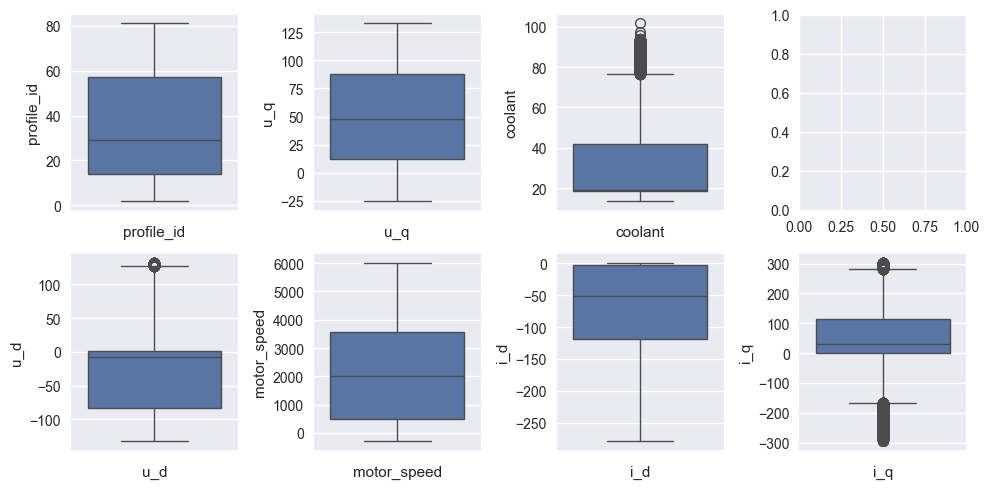

In [46]:
#Boxplot for Outliers
fig, axs = plt.subplots(2,4, figsize = (10,5))
plt1 = sns.boxplot(df_f['profile_id'], ax = axs[0,0]).set(xlabel= 'profile_id')
plt2 = sns.boxplot(df_f['u_q'], ax = axs[0,1]).set(xlabel='u_q')
plt3 = sns.boxplot(df_f['coolant'], ax = axs[0,2]).set(xlabel='coolant')
plt1 = sns.boxplot(df_f['u_d'], ax = axs[1,0]).set(xlabel='u_d')
plt2 = sns.boxplot(df_f['motor_speed'], ax = axs[1,1]).set(xlabel='motor_speed')
plt3 = sns.boxplot(df_f['i_d'], ax = axs[1,2]).set(xlabel='i_d')
plt4 = sns.boxplot(df_f['i_q'], ax = axs[1,3]).set(xlabel='i_q')

plt.tight_layout()


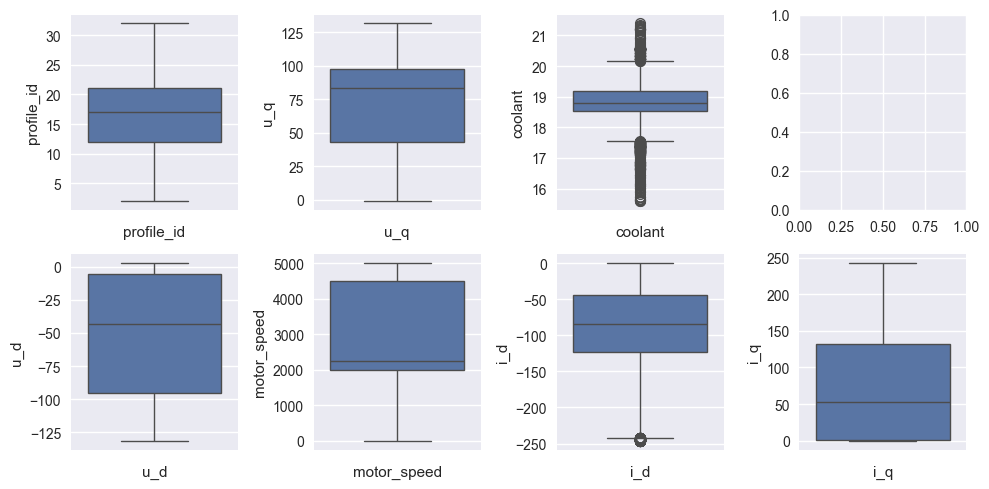

In [47]:
#Boxplot for Outliers
fig, axs = plt.subplots(2,4, figsize = (10,5))
plt1 = sns.boxplot(df_M['profile_id'], ax = axs[0,0]).set(xlabel= 'profile_id')
plt2 = sns.boxplot(df_M['u_q'], ax = axs[0,1]).set(xlabel='u_q')
plt3 = sns.boxplot(df_M['coolant'], ax = axs[0,2]).set(xlabel='coolant')
plt1 = sns.boxplot(df_M['u_d'], ax = axs[1,0]).set(xlabel='u_d')
plt2 = sns.boxplot(df_M['motor_speed'], ax = axs[1,1]).set(xlabel='motor_speed')
plt3 = sns.boxplot(df_M['i_d'], ax = axs[1,2]).set(xlabel='i_d')
plt4 = sns.boxplot(df_M['i_q'], ax = axs[1,3]).set(xlabel='i_q')

plt.tight_layout()


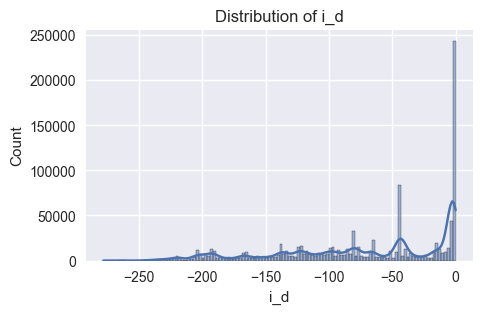

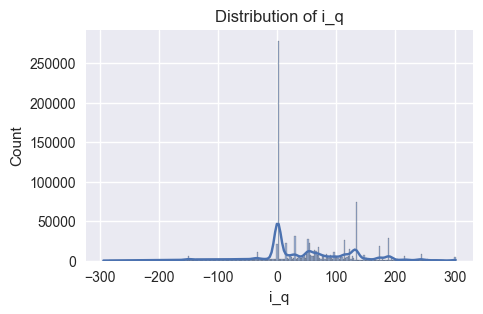

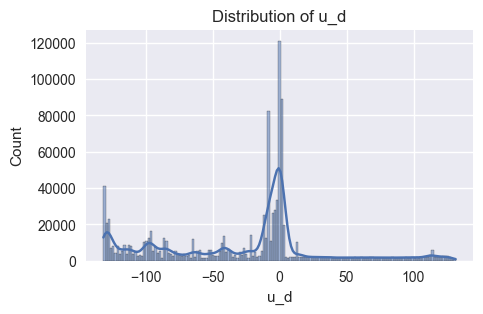

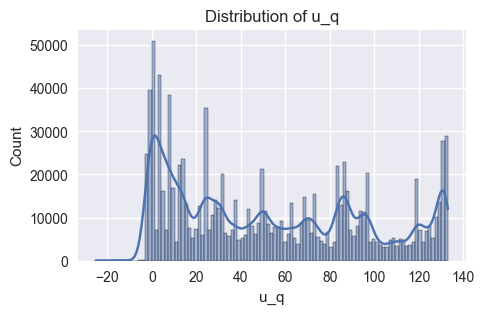

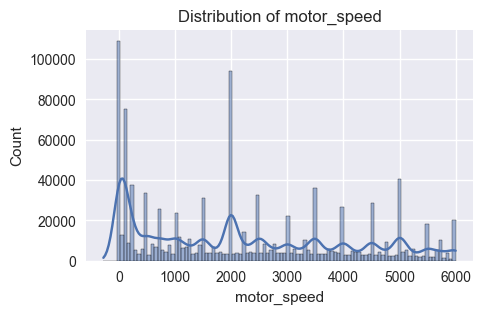

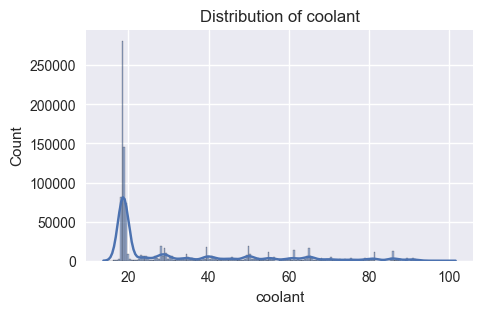

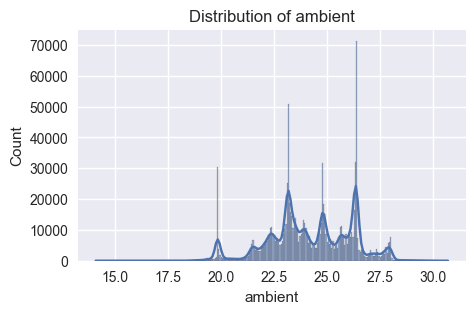

In [48]:
#Step 9 — FEATURE DISTRIBUTIONS
features = ['i_d','i_q','u_d','u_q','motor_speed','coolant','ambient']

for col in features:
    plt.figure(figsize=(5,3))
    sns.histplot(df_f[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

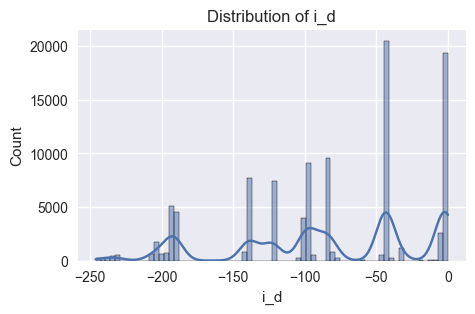

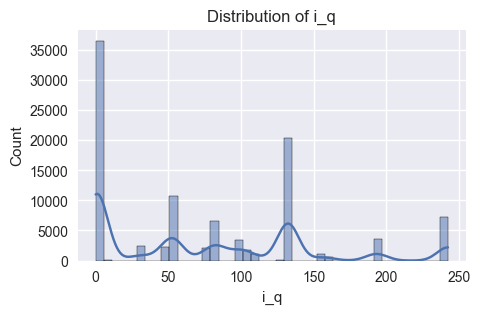

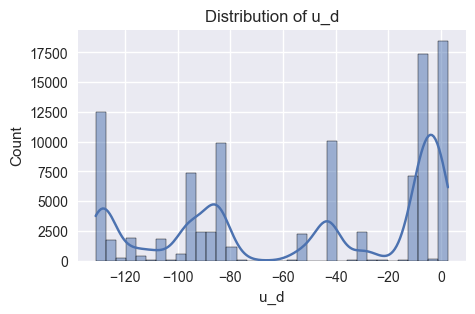

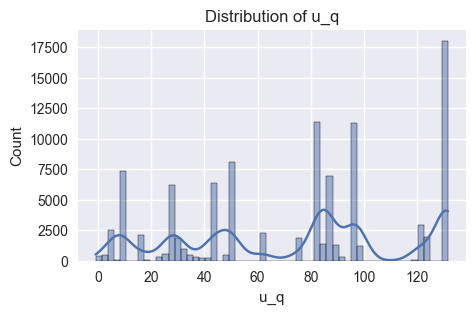

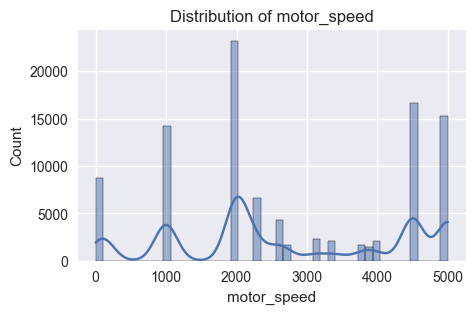

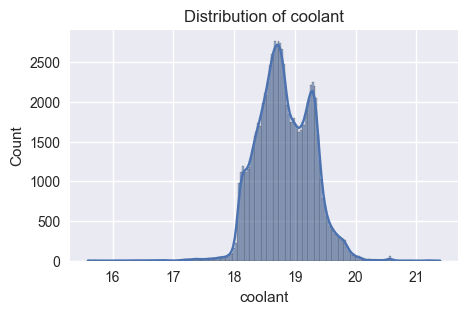

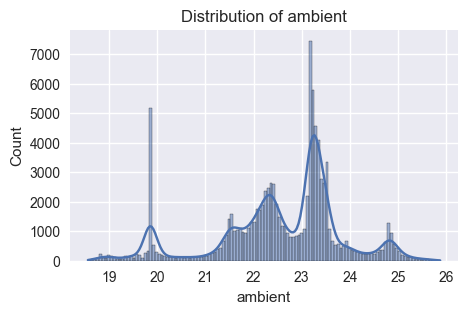

In [49]:
#Distribution for medium dataframe
features = ['i_d','i_q','u_d','u_q','motor_speed','coolant','ambient']

for col in features:
    plt.figure(figsize=(5,3))
    sns.histplot(df_M[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [50]:
#Correlation with Target Only
corr_target = df_f['pm'].sort_values(ascending=False)
corr_target

496278    113.606628
496284    113.600159
496282    113.590591
496283    113.589684
496285    113.576637
             ...    
335830     21.032412
73657      20.894161
73655      20.886429
73656      20.878555
73654      20.856956
Name: pm, Length: 1048575, dtype: float64

In [51]:
#Correlation with Target Only
corr_target = df_M['pm'].sort_values(ascending=False)
corr_target

80302    91.506210
80291    91.386826
80138    91.340919
80292    91.308105
80303    91.263054
           ...    
73658    21.036963
73657    20.894161
73655    20.886429
73656    20.878555
73654    20.856956
Name: pm, Length: 100000, dtype: float64

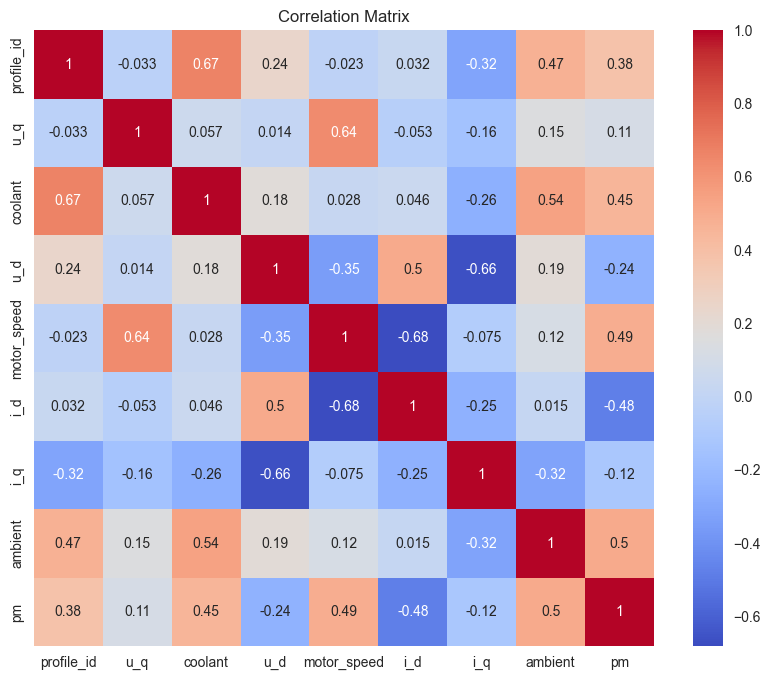

In [52]:
#Step 10 — CORRELATION ANALYSIS
df_f = df_f.apply(pd.to_numeric, errors='coerce')
corr = df_f.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.title("Correlation Matrix")
plt.show()

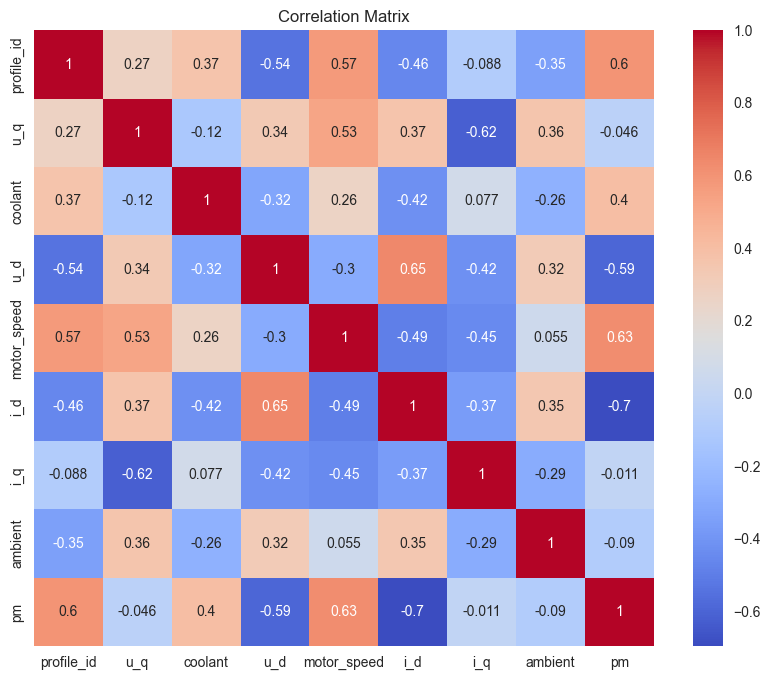

In [53]:
#CORRELATION ANALYSIS
df_M = df_M.apply(pd.to_numeric, errors='coerce')
corr = df_M.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=True)
plt.title("Correlation Matrix")
plt.show()

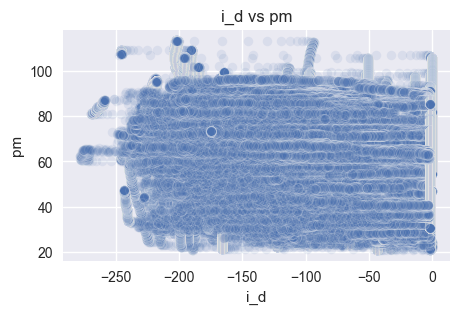

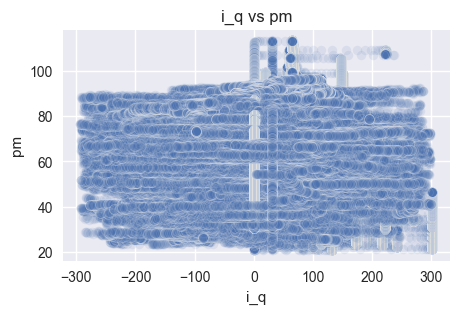

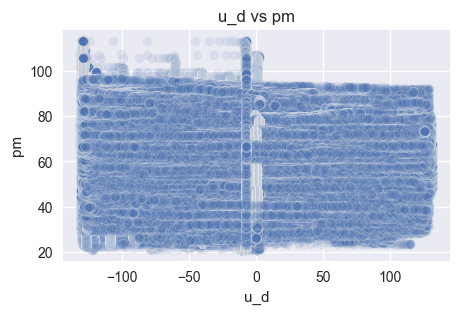

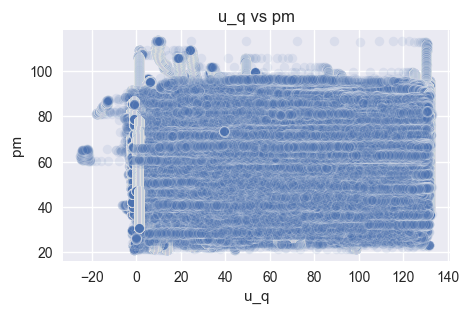

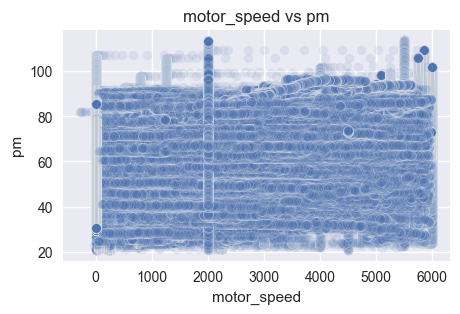

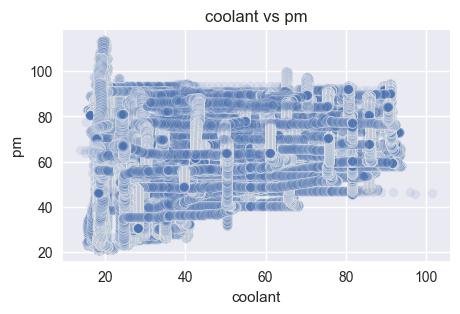

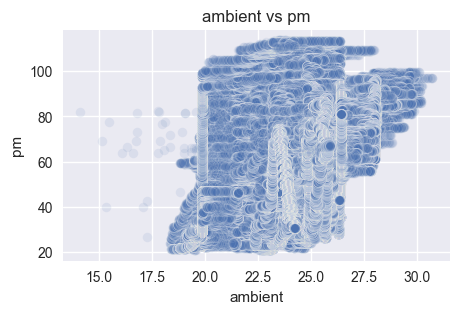

In [54]:
#Step 11 — SCATTER ANALYSIS (Non-Linearity Detection)
for col in features:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df_f[col], y=df_f['pm'], alpha=0.1)
    plt.title(f"{col} vs pm")
    plt.show()

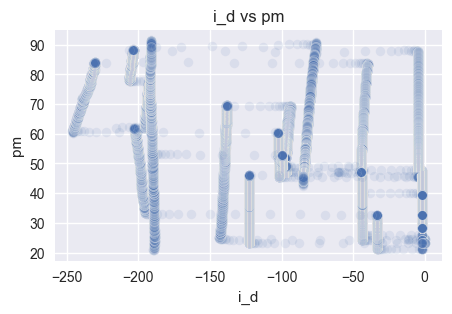

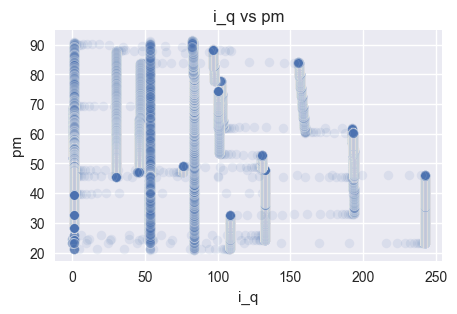

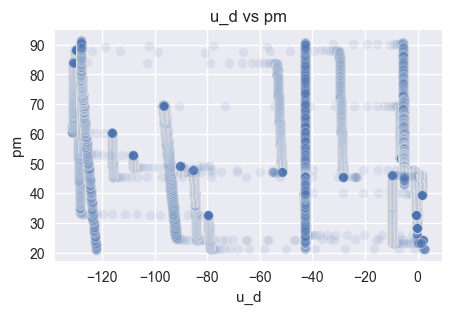

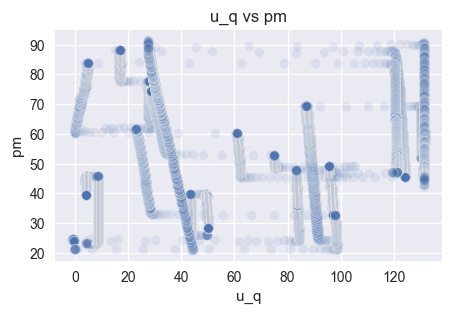

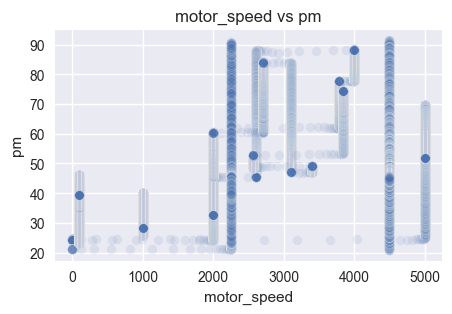

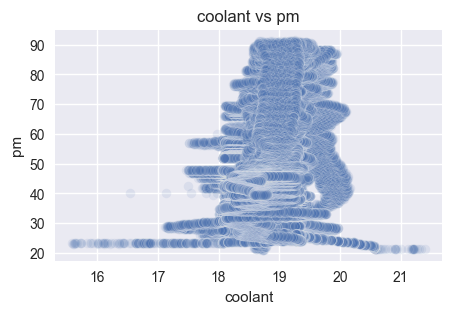

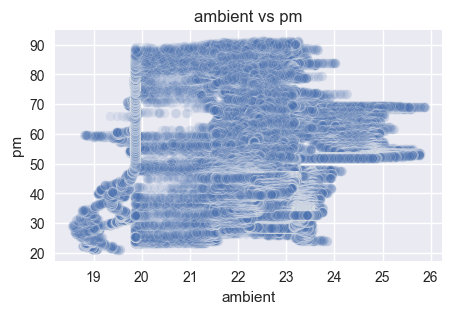

In [55]:
#SCATTER ANALYSIS (Non-Linearity Detection)
for col in features:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=df_M[col], y=df_M['pm'], alpha=0.1)
    plt.title(f"{col} vs pm")
    plt.show()

In [56]:
#Step 12 outlier treatment for i_q and coolant
'''
Q1 = df_f.i_q.quantile(0.25) # data['price'].quantile(0.25)
Q3 = df_f.i_q.quantile(0.75)
IQR = Q3 - Q1
df_f = df_f[(df_f.i_q >= Q1 - 1.5*IQR) & (df_f.i_q <= Q3 + 1.5*IQR)]
print(Q3,Q1)'''
#IQR Outlier Function
def count_iqr_outliers(df, column):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    
    return {
        "Column": column,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": len(outliers),
        "Outlier %": (len(outliers) / len(df)) * 100
    }


#Check for i_q and coolant
count_iqr_outliers(df_f, 'i_q')
count_iqr_outliers(df_f, 'coolant')


{'Column': 'coolant',
 'Lower Bound': np.float64(-16.177634700000006),
 'Upper Bound': np.float64(76.57723154000001),
 'Outlier Count': 60866,
 'Outlier %': 5.804639629974012}

In [57]:
count_iqr_outliers(df_M, 'i_q')
count_iqr_outliers(df_M, 'coolant')

{'Column': 'coolant',
 'Lower Bound': np.float64(17.539467331250002),
 'Upper Bound': np.float64(20.157200341249997),
 'Outlier Count': 560,
 'Outlier %': 0.5599999999999999}

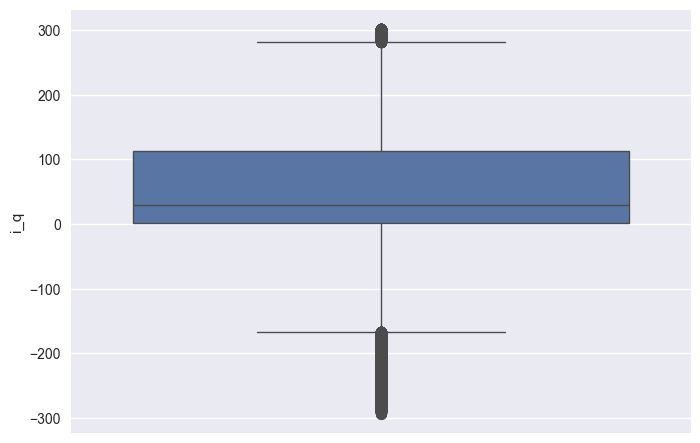

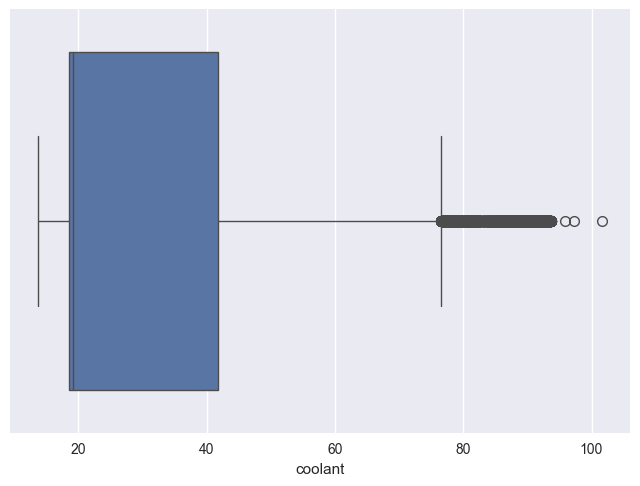

In [58]:
#STep 13 — VISUALIZE BEFORE REMOVING
sns.boxplot(df_f['i_q'])
plt.show()

sns.boxplot(x=df_f['coolant'])
plt.show()

In [59]:
#STEP 14 — Better Than Removing: WINSORIZATION

#Instead of deleting rows, cap them.

def winsorize_column(df, column):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[column] = np.where(df[column] < lower, lower, df[column])
    df[column] = np.where(df[column] > upper, upper, df[column])
    
    return df

In [60]:
df_f = winsorize_column(df_f, 'i_q')
df_f = winsorize_column(df_f, 'coolant')


In [61]:
df_f.shape

(1048575, 9)

In [62]:
df_M = winsorize_column(df_M, 'i_q')
df_M = winsorize_column(df_M, 'coolant')

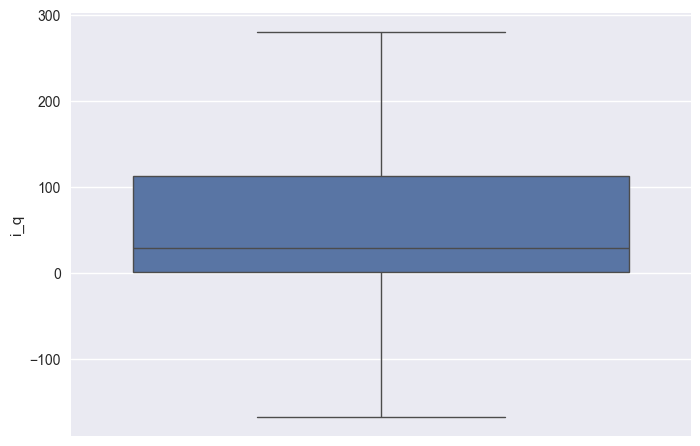

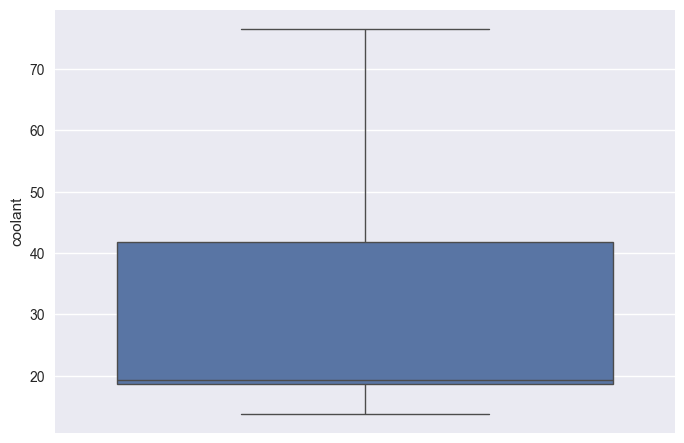

In [63]:
sns.boxplot(y=df_f['i_q'])
plt.show()

sns.boxplot(y=df_f['coolant'])
plt.show()


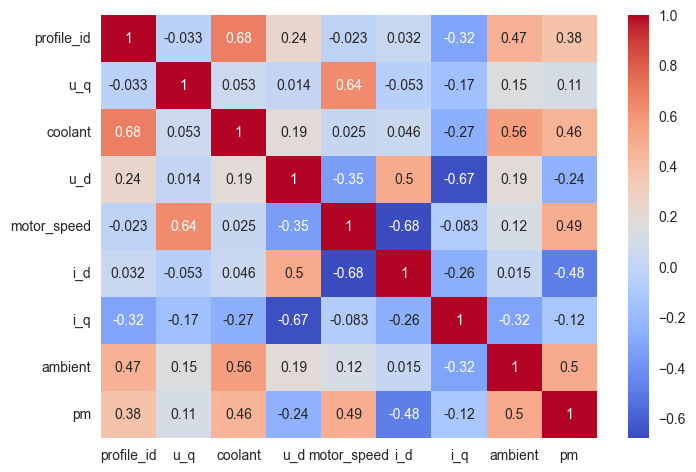

In [64]:
#STEP 15 — Correlation Check
df_f = df_f.apply(pd.to_numeric, errors='coerce')
corr_matrix = df_f.corr()

sns.heatmap(corr_matrix, cmap="coolwarm",annot = True)
plt.show()

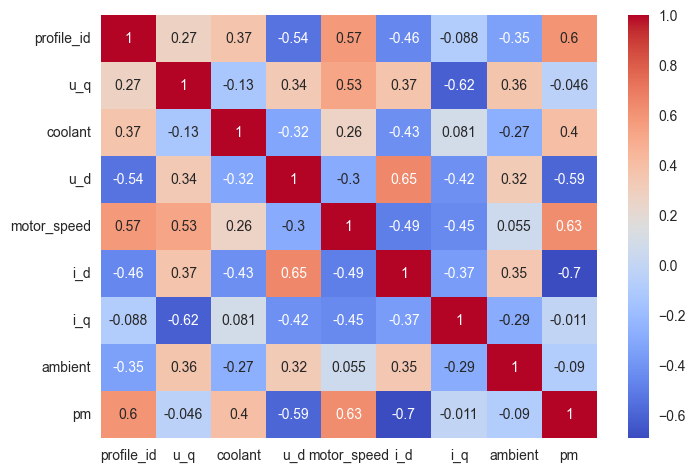

In [65]:
#Correlation Check
df_M = df_M.apply(pd.to_numeric, errors='coerce')
corr_matrix = df_M.corr()

sns.heatmap(corr_matrix, cmap="coolwarm",annot = True)
plt.show()

In [66]:
corr_matrix['pm'].sort_values(ascending=False)


pm             1.000000
motor_speed    0.626576
profile_id     0.596961
coolant        0.402856
i_q           -0.010675
u_q           -0.045896
ambient       -0.090039
u_d           -0.592292
i_d           -0.695819
Name: pm, dtype: float64

In [67]:
#STEP 16 — FEATURE ENGINEERING AS A FUNCTION
'''def add_engineered_features(df):
    df_M = df_M.copy()
    df_M['current_magnitude'] = np.sqrt(df_M['i_d']**2 + df_M['i_q']**2)
    df_M['voltage_magnitude'] = np.sqrt(df_M['u_d']**2 + df_M['u_q']**2)
    df_M['power_proxy'] = df_M['current_magnitude'] * df_M['voltage_magnitude']
    return df_M'''
'''What we apply:

Mean imputation (for missing sensor values)

Standard scaling (for linear models)'''
def add_engineered_features(df):

    df = df.copy()

    df["current_magnitude"] = np.sqrt(df["i_d"]**2 + df["i_q"]**2)

    df["voltage_magnitude"] = np.sqrt(df["u_d"]**2 + df["u_q"]**2)

    df["power_proxy"] = df["current_magnitude"] * df["voltage_magnitude"]

    return df


In [68]:
df_M = add_engineered_features(df_M)
df_f = add_engineered_features(df_f)

In [69]:
#Step 17 Train and Test split

In [70]:
'''Custom Transformer (VERY IMPORTANT CONCEPT)
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np

class FeatureEngineer(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        X['current_magnitude'] = np.sqrt(X['i_d']**2 + X['i_q']**2)
        X['voltage_magnitude'] = np.sqrt(X['u_d']**2 + X['u_q']**2)
        X['power_proxy'] = X['current_magnitude'] * X['voltage_magnitude']
        
        return X'''

X = df_M.drop("pm", axis=1)
y = df_M["pm"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [71]:
#STEP 18 — FULL PREPROCESSING PIPELINE

In [72]:
preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [73]:
#Step 19 - Model pipelines(All pipelines)
pipelines = {

"Ridge": Pipeline([
("prep", preprocess),
("model", Ridge())
]),

"SVR": Pipeline([
("prep", preprocess),
("model", SVR())
]),

"KNN": Pipeline([
("prep", preprocess),
("model", KNeighborsRegressor())
]),

"RandomForest": Pipeline([
("prep", preprocess),
("model", RandomForestRegressor(n_estimators=200))
]),

"LightGBM": Pipeline([
("prep", preprocess),
("model", LGBMRegressor())
]),

"XGBoost": Pipeline([
("prep", preprocess),
("model", XGBRegressor())
])
}



In [74]:
#Step 20- Baseline model training
results = []

for name, model in pipelines.items():

    print("Training:", name)

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

Training: Ridge
Training: SVR
Training: KNN
Training: RandomForest
Training: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004580 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 11
[LightGBM] [Info] Start training from score 49.747463


C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Training: XGBoost


In [75]:
#Step 21 - Find the best models with best MAE value
results_df = pd.DataFrame(results)

results_df = results_df.sort_values("MAE")

results_df


,Model,MAE,RMSE,R2
3,RandomForest,0.251197,0.704632,0.998075
5,XGBoost,0.514416,0.959047,0.996434
4,LightGBM,0.726431,1.252640,0.993916
2,KNN,1.771974,3.005552,0.964974
1,SVR,3.225845,5.731296,0.872636
0,Ridge,5.949146,8.220819,0.737958


In [76]:
#Step 22- Locate the best model or select the top model
top_models = results_df["Model"].iloc[:3].tolist()

print("Top Models:", top_models)

Top Models: ['RandomForest', 'XGBoost', 'LightGBM']


In [77]:
#Hyperparameter grid
param_grids = {

"RandomForest": {
"model__n_estimators":[200,300],
"model__max_depth":[10,20]
},

"LightGBM": {
"model__n_estimators":[300,400],
"model__learning_rate":[0.01,0.05],
"model__num_leaves":[31,50]
},

"XGBoost": {
"model__n_estimators":[300,400],
"model__learning_rate":[0.01,0.05],
"model__max_depth":[4,6]
}
}

In [78]:
# Step 23 - Hyperparameter Fine tuning Function
def tune_model(model_pipeline, param_grid, X_train, y_train):

    search = RandomizedSearchCV(
        estimator=model_pipeline,
        param_distributions=param_grid,
        n_iter=5,
        cv=2,
        scoring="neg_mean_absolute_error",
        n_jobs=1,
        verbose=2,
        random_state=42
    )

    search.fit(X_train, y_train)

    print("Best Params:", search.best_params_)

    return search.best_estimator_

In [79]:
#Step 24 - Tune Top Model
tuned_models = {}

for name in top_models:

    if name in param_grids:

        tuned_models[name] = tune_model(
            pipelines[name],
            param_grids[name],
            X_train,
            y_train
        )

Fitting 2 folds for each of 4 candidates, totalling 8 fits


C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=5. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END .......model__max_depth=10, model__n_estimators=200; total time= 1.8min
[CV] END .......model__max_depth=10, model__n_estimators=200; total time= 1.7min
[CV] END .......model__max_depth=10, model__n_estimators=300; total time= 2.6min
[CV] END .......model__max_depth=10, model__n_estimators=300; total time= 2.6min
[CV] END .......model__max_depth=20, model__n_estimators=200; total time= 2.8min
[CV] END .......model__max_depth=20, model__n_estimators=200; total time= 2.8min
[CV] END .......model__max_depth=20, model__n_estimators=300; total time= 4.1min
[CV] END .......model__max_depth=20, model__n_estimators=300; total time= 3.9min
Best Params: {'model__n_estimators': 300, 'model__max_depth': 20}
Fitting 2 folds for each of 5 candidates, totalling 10 fits
[CV] END model__learning_rate=0.01, model__max_depth=4, model__n_estimators=400; total time=   0.9s
[CV] END model__learning_rate=0.01, model__max_depth=4, model__n_estimators=400; total time=   0.9s
[CV] END model__learning_r

C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__learning_rate=0.01, model__n_estimators=300, model__num_leaves=50; total time=   1.4s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002208 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] Start training from score 49.715631


C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__learning_rate=0.01, model__n_estimators=300, model__num_leaves=50; total time=   1.3s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001939 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] Start training from score 49.779296


C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__learning_rate=0.05, model__n_estimators=300, model__num_leaves=50; total time=   1.1s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001914 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] Start training from score 49.715631


C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__learning_rate=0.05, model__n_estimators=300, model__num_leaves=50; total time=   1.1s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] Start training from score 49.779296


C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__learning_rate=0.01, model__n_estimators=300, model__num_leaves=31; total time=   1.0s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001876 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] Start training from score 49.715631


C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__learning_rate=0.01, model__n_estimators=300, model__num_leaves=31; total time=   1.0s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001926 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] Start training from score 49.779296


C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__learning_rate=0.05, model__n_estimators=400, model__num_leaves=50; total time=   1.4s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001887 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] Start training from score 49.715631


C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__learning_rate=0.05, model__n_estimators=400, model__num_leaves=50; total time=   1.4s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001889 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] Start training from score 49.779296


C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__learning_rate=0.01, model__n_estimators=400, model__num_leaves=31; total time=   1.3s
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001955 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 11
[LightGBM] [Info] Start training from score 49.715631


C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__learning_rate=0.01, model__n_estimators=400, model__num_leaves=31; total time=   1.3s
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001048 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2557
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 11
[LightGBM] [Info] Start training from score 49.747463
Best Params: {'model__num_leaves': 50, 'model__n_estimators': 400, 'model__learning_rate': 0.05}


In [80]:
#Step 25 - Select Best model
best_model = tuned_models[top_models[0]]
tuned_models
best_model

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imputer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None


In [81]:
print(top_models[0])
print(top_models[1])
print(top_models[2])

RandomForest
XGBoost
LightGBM


In [82]:
df_f.shape

(1048575, 12)

In [83]:
#Step 26 - Train on Full Dataset
# Prepare Full Dataset

results_f = []

X_full = df_f.drop("pm", axis=1)
y_full = df_f["pm"]

# reduce memory
X_full = X_full.astype("float32")
y_full = y_full.astype("float32")

print("Full dataset shape:", X_full.shape)

for name in top_models:

    print("Training on full dataset:", name)

    model = tuned_models[name]   # get tuned model

    model.fit(X_full, y_full)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results_f.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


results_f = pd.DataFrame(results_f).sort_values("MAE")

print(results_f)
#print(results_f[0])
best_model = tuned_models[results_f[0]]

Full dataset shape: (1048575, 11)
Training on full dataset: RandomForest
Training on full dataset: XGBoost
Training on full dataset: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016690 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2605
[LightGBM] [Info] Number of data points in the train set: 1048575, number of used features: 11
[LightGBM] [Info] Start training from score 56.910774
          Model       MAE      RMSE        R2
0  RandomForest  0.578506  1.997211  0.984534
2      LightGBM  1.905141  2.973626  0.965714
1       XGBoost  2.224525  3.423955  0.954543


C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


NameError: name 'results_f' is not defined

NameError: name 'results_f' is not defined

              Feature  Importance
2             coolant    0.352231
4         motor_speed    0.180659
7             ambient    0.125620
3                 u_d    0.086834
0          profile_id    0.076381
9   voltage_magnitude    0.042414
1                 u_q    0.042024
5                 i_d    0.033870
6                 i_q    0.022528
10        power_proxy    0.022417
8   current_magnitude    0.015022


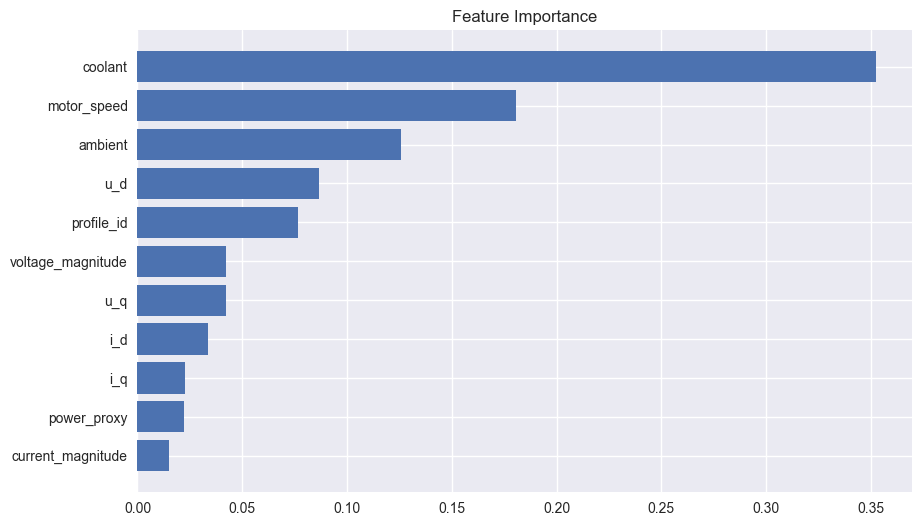

In [84]:
#feature importance and LIME and SHAP.
import matplotlib.pyplot as plt
import pandas as pd

model = best_model.named_steps["model"]

importances = model.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(10,6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.show()

In [85]:
#LIME (Local Explainability)
%pip install lime

In [90]:
X_train.head()

,profile_id,u_q,coolant,u_d,motor_speed,i_d,i_q,ambient,current_magnitude,voltage_magnitude,power_proxy
75220,21,31.472158,18.592873,-127.152069,4499.966309,-191.637253,83.851448,19.850620,209.179115,130.989104,27400.184855
48955,12,97.209305,18.429920,-0.416453,1999.977783,-2.001353,1.097026,23.233452,2.282296,97.210197,221.862485
44966,12,96.780548,18.421989,-0.793596,1999.979492,-2.001167,1.096949,23.334099,2.282097,96.783802,220.870043
13568,17,131.012283,19.295425,-6.363523,4999.949707,-96.711594,0.885709,24.812164,96.715649,131.166737,12685.876103
92727,2,8.782465,18.101448,-9.786176,100.040688,-122.972763,242.423538,21.552696,271.829859,13.149180,3574.339663


In [92]:
X_train.isnull().sum()

profile_id           1871
u_q                     0
coolant                 0
u_d                     0
motor_speed             0
i_d                     0
i_q                     0
ambient                 0
current_magnitude       0
voltage_magnitude       0
power_proxy             0
dtype: int64

In [96]:
df_f['profile_id'].fillna(df_f['profile_id'].mode(),inplace=True)

In [97]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    mode='regression'
)

exp = explainer.explain_instance(
    X_test.iloc[0],
    best_model.predict
)

exp.show_in_notebook()

C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\lime\discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\lime\lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beh

In [88]:
#Shap (Local and Global explainability)
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [1]:
#selecting the best model for full data set.
best_model = tuned_models[results_f[0]]

NameError: name 'tuned_models' is not defined

In [99]:
import shap

model = best_model.named_steps["model"]

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

MemoryError: Unable to allocate 2.27 MiB for an array with shape (297681, 1) and data type float64

In [ ]:
shap.summary_plot(shap_values, X_test)

In [ ]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

In [105]:
#Step 27 - Save the model as a pickle using joblib
joblib.dump(best_model, "pmsm_model.pkl")

print("Model Saved")

Model Saved


In [106]:
%pip install streamlit

In [1]:
#Step 28 - Streamlit APP
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("pmsm_model.pkl")

st.title("PMSM Temperature Prediction")

profile_id = st.number_input("Profile ID")
u_q = st.number_input("u_q")
coolant = st.number_input("coolant")
u_d = st.number_input("u_d")
motor_speed = st.number_input("motor_speed")
i_d = st.number_input("i_d")
i_q = st.number_input("i_q")
ambient = st.number_input("ambient")

current_mag = (i_d**2 + i_q**2)**0.5
voltage_mag = (u_d**2 + u_q**2)**0.5
power_proxy = current_mag * voltage_mag

data = pd.DataFrame([[

profile_id,u_q,coolant,u_d,motor_speed,i_d,i_q,ambient,
current_mag,voltage_mag,power_proxy

]],columns=[

"profile_id","u_q","coolant","u_d","motor_speed",
"i_d","i_q","ambient",
"current_magnitude","voltage_magnitude","power_proxy"

])

if st.button("Predict Temperature"):

    prediction = model.predict(data)

    st.success(f"Predicted PM Temperature: {prediction[0]:.2f}")

2026-03-19 19:48:47.620 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 19:48:51.109 
  command:

    streamlit run C:\Users\Pavan\anaconda3\envs\pmsm_ml\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-19 19:48:51.109 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 19:48:51.113 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 19:48:51.113 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 19:48:51.118 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 19:48:51.121 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-19 19:48:51.124 Thread 'Ma